In [ ]:
# printeaza captions from all eight files

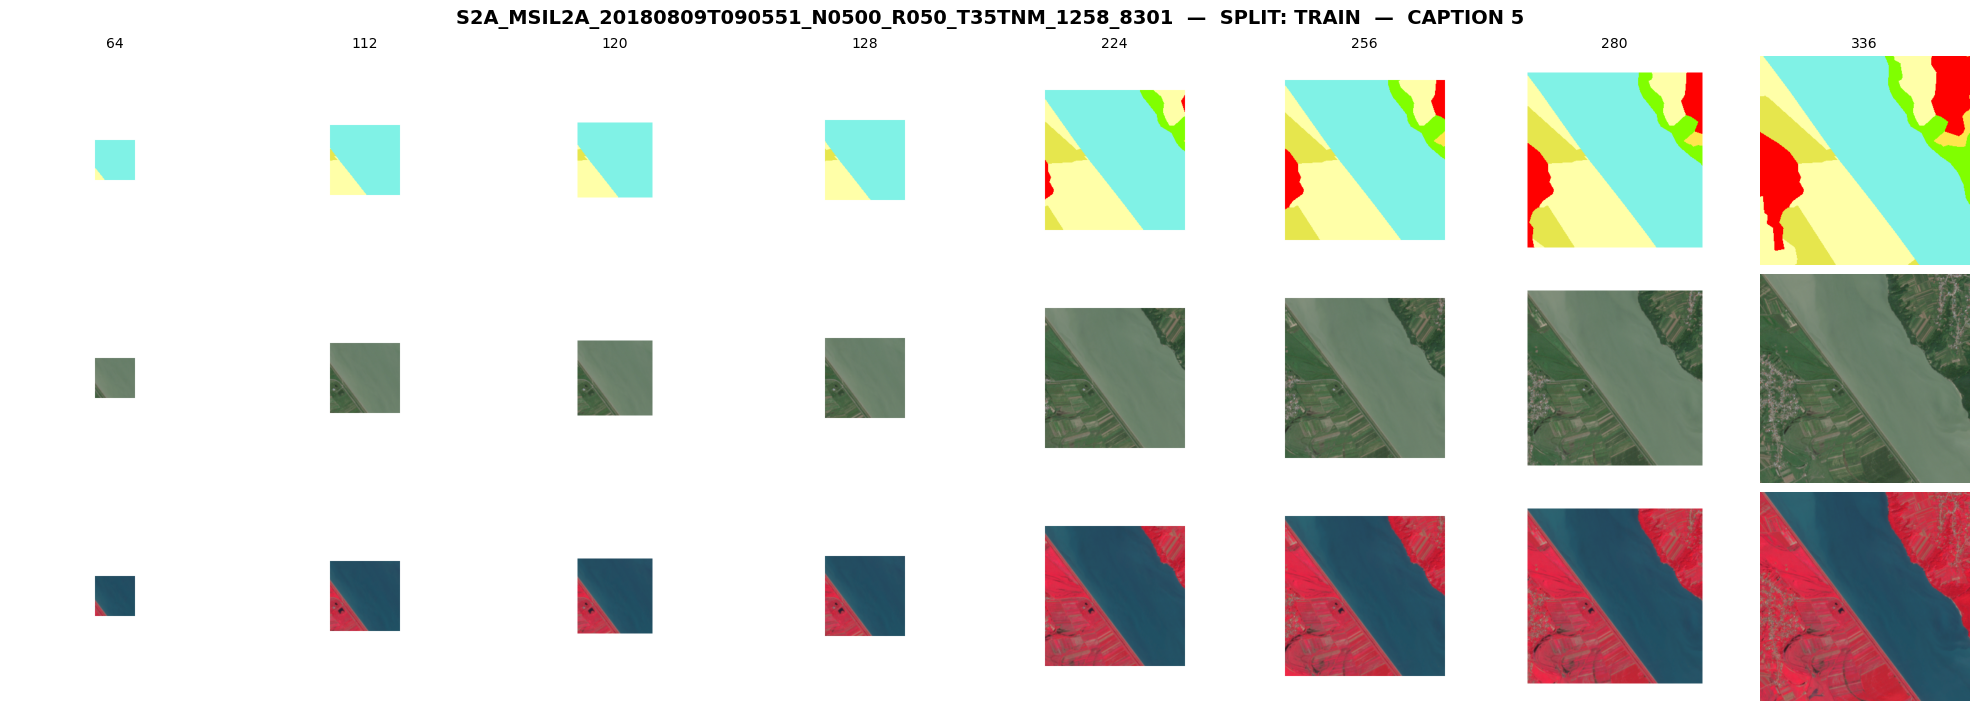

Index: 6  |  BaseFilename: S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1258_8301
Split: TRAIN
BaseFolder: S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM
 64: inland waters, agriculture
112: inland waters, agriculture
120: inland waters, agriculture
128: inland waters, agriculture
224: inland waters, agriculture, pastures, forest
256: inland waters, agriculture, pastures, forest, urban fabric
280: inland waters, agriculture, pastures, urban fabric, forest
336: inland waters, agriculture, pastures, urban fabric, forest


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Patch visualizer (clean final version)
======================================

Displays corresponding patches across scales using folder structure:

/dataset_root/PNG/
  Patch_<size>/
    TrueColor_RGB/<BaseFolder>/
    FalseColor_NIR/<BaseFolder>/
    CLC_reference_RGB/<BaseFolder>/
  metadata_<size>.parquet
"""

# =============================================================================
# IMPORTS
# =============================================================================
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# =============================================================================
# CONFIGURATION
# =============================================================================
ROOT_DIR = "/dataset_root/PNG"
patch_sizes = [64, 112, 120, 128, 224, 256, 280, 336]

meta_files = [os.path.join(ROOT_DIR, f"Patch_{s}", f"metadata_{s}.parquet") for s in patch_sizes]
png_roots  = [os.path.join(ROOT_DIR, f"Patch_{s}") for s in patch_sizes]

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def pad_to_336(img, target_size=336):
    h, w = img.shape[:2]
    pad_h = target_size - h
    pad_w = target_size - w
    top, bottom = pad_h // 2, pad_h - pad_h // 2
    left, right = pad_w // 2, pad_w - pad_w // 2
    pad_value = 255 if img.dtype == np.uint8 else 1.0
    return np.pad(img, ((top, bottom), (left, right), (0, 0)), constant_values=pad_value)

# =============================================================================
# LOAD METADATA FILES
# =============================================================================
dfs = []
for path in meta_files:
    if not os.path.exists(path):
        print(f"⚠ Missing {path}")
        continue
    df = pd.read_parquet(path)
    df["PatchSize"] = int(os.path.basename(path).split("_")[1].split(".")[0])
    dfs.append(df.set_index("BaseFilename"))
    print(f"✅ Loaded {os.path.basename(path)} with {len(df)} rows.")

if not dfs:
    raise RuntimeError("No metadata parquet files loaded successfully.")

df_ref = dfs[-1].reset_index()
idx = 0

# =============================================================================
# CHOOSE CAPTION
# =============================================================================
while True:
    try:
        caption_num = int(input("Choose caption number (1–5): ").strip())
        if caption_num in range(1, 6):
            break
    except ValueError:
        pass
    print("Please enter a valid integer between 1 and 5.")

# =============================================================================
# MAIN LOOP
# =============================================================================
while True:
    inp = input("\nEnter row number, BaseFilename, 'n'=next, 'p'=prev, 'q'=quit: ").strip().lower()
    if inp == 'q':
        break
    elif inp == '' or inp == 'n':
        idx = min(idx + 1, len(df_ref) - 1)
    elif inp == 'p':
        idx = max(idx - 1, 0)
    elif inp.isdigit():
        val = int(inp)
        if 0 <= val < len(df_ref):
            idx = val
        else:
            print(f"Row number must be between 0 and {len(df_ref)-1}")
            continue
    else:
        if inp in df_ref["BaseFilename"].values:
            idx = df_ref.index[df_ref["BaseFilename"] == inp][0]
        else:
            print("Invalid input.")
            continue

    row_ref = df_ref.iloc[idx]
    base_folder = row_ref["BaseFolder"]
    base_filename = row_ref["BaseFilename"]
    split = row_ref.get("split", "unknown").upper()

    image_grid = [[], [], []]
    caption_list = []

    # -------------------------------------------------------------------------
    # Load images per patch size
    # -------------------------------------------------------------------------
    for df, size, root in zip(dfs, patch_sizes, png_roots):
        if base_filename not in df.index:
            for _ in range(3):
                image_grid[_].append(None)
            caption_list.append(f"{size:>3}: [Missing metadata]")
            continue

        entry = df.loc[base_filename]

        truecolor_path = os.path.join(root, "TrueColor_RGB", base_folder, base_filename + "_B432.png")
        falsecolor_path = os.path.join(root, "FalseColor_NIR", base_folder, base_filename + "_B843.png")
        clc_path = os.path.join(root, "CLC_reference_RGB", base_folder, base_filename + "_CLC_RGB.png")

        paths = [clc_path, truecolor_path, falsecolor_path]

        for i, path in enumerate(paths):
            if not os.path.exists(path):
                image_grid[i].append(None)
                continue
            arr = cv2.imread(path, cv2.IMREAD_COLOR)
            if arr is None:
                image_grid[i].append(None)
                continue
            arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
            arr = pad_to_336(arr)
            image_grid[i].append(arr)

        caption_key = f"caption{caption_num}"
        cap_text = str(entry.get(caption_key, "")).strip() or "[No caption]"
        caption_list.append(f"{size:>3}: {cap_text}")

    # -------------------------------------------------------------------------
    # DISPLAY GRID
    # -------------------------------------------------------------------------
    clear_output(wait=True)
    fig, axs = plt.subplots(
        3, len(patch_sizes),
        figsize=(2.5 * len(patch_sizes), 7),
        constrained_layout=True
    )

    for r in range(3):
        for c, size in enumerate(patch_sizes):
            ax = axs[r, c]
            ax.axis('off')
            img = image_grid[r][c]
            if img is not None:
                ax.imshow(img)
            if r == 0:
                ax.set_title(str(size), fontsize=10)

    plt.suptitle(f"{base_filename}  —  SPLIT: {split}  —  CAPTION {caption_num}", fontsize=14, fontweight='bold')
    plt.show()

    # -------------------------------------------------------------------------
    # CAPTIONS PRINT
    # -------------------------------------------------------------------------
    print("=" * 90)
    print(f"Index: {idx}  |  BaseFilename: {base_filename}")
    print(f"Split: {split}")
    print(f"BaseFolder: {base_folder}")
    print("=" * 90)
    for cap in caption_list:
        print(cap)
    print("=" * 90)
